# Decision Tree (High Correlation Data) [0.7511]

In [ ]:
def correlation_func(filepath, targetcolumn, threshold):
    df = pd.read_csv(filepath)
    df = df.drop(columns=['Refcode', 'Point group'])
    matrix = df.corr()
    target_correlations = matrix[targetcolumn]
    target_correlations = target_correlations.drop(labels=[targetcolumn])

    selected_columns = []
    for feature, correlation in target_correlations.items():
        if correlation > threshold:
            selected_columns.append(feature)
        elif correlation < -threshold:
            selected_columns.append(feature)
    
    selected_columns.append(targetcolumn)
    filtered_df = df[selected_columns]
    
    return filtered_df

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import joblib

# Load the dataset
data = r'filtered and normalised all descriptor data.csv'

correlated_df = correlation_func(data, 'Target', 0.1)

# Initialize variables to track best model and accuracies
best_accuracy = 0
best_model = None
titleacc = 0
accuracies = []

# Run the model 100 times
for i in range(100):

    # Load the dataset
    df = correlated_df

    # Balancing the dataset
    df_target_0 = df[df['Target'] == 0.0]
    df_target_1 = df[df['Target'] == 1.0]
    rows_df_target_0 = df_target_0.shape[0]
    rows_df_target_1 = df_target_1.shape[0]

    if rows_df_target_0 < rows_df_target_1:
        smaller_df = df_target_0
        larger_df = df_target_1
        smaller_rows = rows_df_target_0
    else:
        smaller_df = df_target_1
        larger_df = df_target_0
        smaller_rows = rows_df_target_1

    scaled_larger_df = larger_df.sample(n=smaller_rows)
    balanced_df = pd.concat([smaller_df, scaled_larger_df], axis=0)
    shuffled_balanced_df = balanced_df.sample(frac=1).reset_index(drop=True)

    # Separate features and target
    feature_df = shuffled_balanced_df.drop(columns=['Target'])
    X = feature_df.drop(columns='Target')
    y = np.asarray(shuffled_balanced_df['Target'])

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
    
    # Train the model
    dtc = DecisionTreeClassifier()
    dtc.fit(X_train, y_train)
    
    # Predict on the test set
    y_pred = dtc.predict(X_test)
    
    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f'Accuracy of Run {i+1}: {acc}')
    accuracies.append(acc)
    
    # Check if this is the best model so far
    if acc > best_accuracy:
        best_accuracy = acc
        titleacc = acc
        best_model = dtc

# Calculate average accuracy
average_accuracy = np.mean(accuracies)
print(f'\nAverage Accuracy over 100 runs: {average_accuracy:.4f}')

# Display the confusion matrix of the best model
ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    display_labels=["Sohncke", "Racemic"],
    cmap=plt.cm.Blues,
    values_format='d'
)
plt.title(f'Best Confusion Matrix (Decision Tree) [Accuracy: {titleacc:.2f}]')
plt.show()

KeyError: "['Target'] not found in axis"

Accuracy of Run 1: 0.5000
Accuracy of Run 2: 0.6538
Accuracy of Run 3: 0.6538
Accuracy of Run 4: 0.5769
Accuracy of Run 5: 0.6538
Accuracy of Run 6: 0.5385
Accuracy of Run 7: 0.5000
Accuracy of Run 8: 0.6923
Accuracy of Run 9: 0.5000
Accuracy of Run 10: 0.3846
Accuracy of Run 11: 0.6154
Accuracy of Run 12: 0.4615
Accuracy of Run 13: 0.5769
Accuracy of Run 14: 0.5000
Accuracy of Run 15: 0.5385
Accuracy of Run 16: 0.4615
Accuracy of Run 17: 0.5000
Accuracy of Run 18: 0.3846
Accuracy of Run 19: 0.5000
Accuracy of Run 20: 0.4615
Accuracy of Run 21: 0.3846
Accuracy of Run 22: 0.6154
Accuracy of Run 23: 0.5385
Accuracy of Run 24: 0.5769
Accuracy of Run 25: 0.4615
Accuracy of Run 26: 0.3462
Accuracy of Run 27: 0.8077
Accuracy of Run 28: 0.5385
Accuracy of Run 29: 0.5385
Accuracy of Run 30: 0.5000
Accuracy of Run 31: 0.5000
Accuracy of Run 32: 0.6154
Accuracy of Run 33: 0.4615
Accuracy of Run 34: 0.5385
Accuracy of Run 35: 0.6154
Accuracy of Run 36: 0.5385
Accuracy of Run 37: 0.5385
Accuracy o

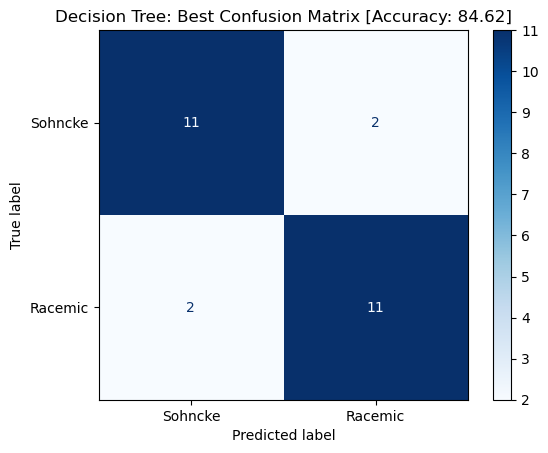

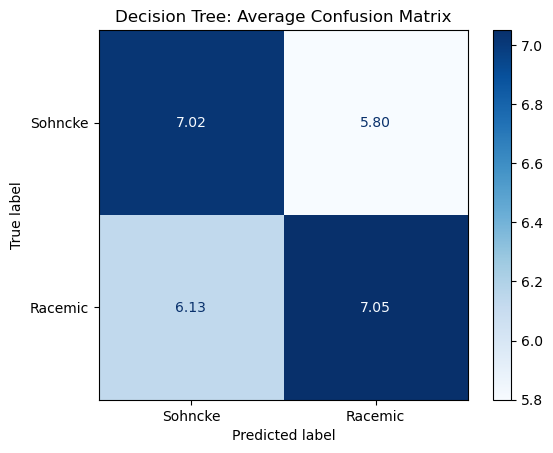

Best model saved as best_decision_tree_model_gen_3_mac.pkl


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import joblib

# Load the dataset
data = r'filtered and normalised all descriptor data.csv'

correlated_df = correlation_func(data, 'Target', 0.1)

# Initialize variables to track best model and accuracies
best_accuracy = 0
best_model = None
titleacc = 0
accuracies = []
confusion_matrices = []

# Run the model 100 times
for i in range(100):

    # Load the dataset
    df = correlated_df

    # Split data based on the target column
    df_target_0 = df[df['Target'] == 0.0]
    df_target_1 = df[df['Target'] == 1.0]
    rows_df_target_0 = df_target_0.shape[0]
    rows_df_target_1 = df_target_1.shape[0]

    if rows_df_target_0 < rows_df_target_1:
        smaller_df = df_target_0
        larger_df = df_target_1
        smaller_rows = rows_df_target_0
    else:
        smaller_df = df_target_1
        larger_df = df_target_0
        smaller_rows = rows_df_target_1

    scaled_larger_df = larger_df.sample(n=smaller_rows)
    balanced_df = pd.concat([smaller_df, scaled_larger_df], axis=0)
    shuffled_balanced_df = balanced_df.sample(frac=1).reset_index(drop=True)
    shuffled_balanced_cleaned_df = shuffled_balanced_df
    feature_df = shuffled_balanced_cleaned_df.drop(columns=['Target'])
        
    X = feature_df
    y = np.asarray(shuffled_balanced_cleaned_df['Target'])
    
    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
    
    # Train the model
    dtc = DecisionTreeClassifier()
    dtc.fit(X_train, y_train)
    
    # Predict on the test set
    y_pred = dtc.predict(X_test)
    
    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f'Accuracy of Run {i+1}: {acc:.4f}')
    accuracies.append(acc)
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Check if this is the best model so far
    if acc > best_accuracy:
        best_accuracy = acc
        titleacc = acc
        best_model = dtc
        best_confusion_matrix = cm

# Calculate average accuracy
average_accuracy = np.mean(accuracies)
print(f'\nAverage Accuracy over 100 runs: {average_accuracy*100:.2f}')

# Calculate the average confusion matrix
average_confusion_matrix = np.mean(confusion_matrices, axis=0)

# Display the best confusion matrix
ConfusionMatrixDisplay(best_confusion_matrix, display_labels=["Sohncke", "Racemic"]).plot(
    cmap=plt.cm.Blues, values_format='d'
)
plt.title(f'Decision Tree: Best Confusion Matrix [Accuracy: {titleacc * 100:.2f}]')
plt.show()

# Display the average confusion matrix
ConfusionMatrixDisplay(average_confusion_matrix, display_labels=["Sohncke", "Racemic"]).plot(
    cmap=plt.cm.Blues, values_format='.2f'
)
plt.title(f'Decision Tree: Average Confusion Matrix')
plt.show()

# Save the best model
model_filename = "best_decision_tree_model_gen_3_mac.pkl"
joblib.dump(best_model, model_filename)

print(f'Best model saved as {model_filename}')


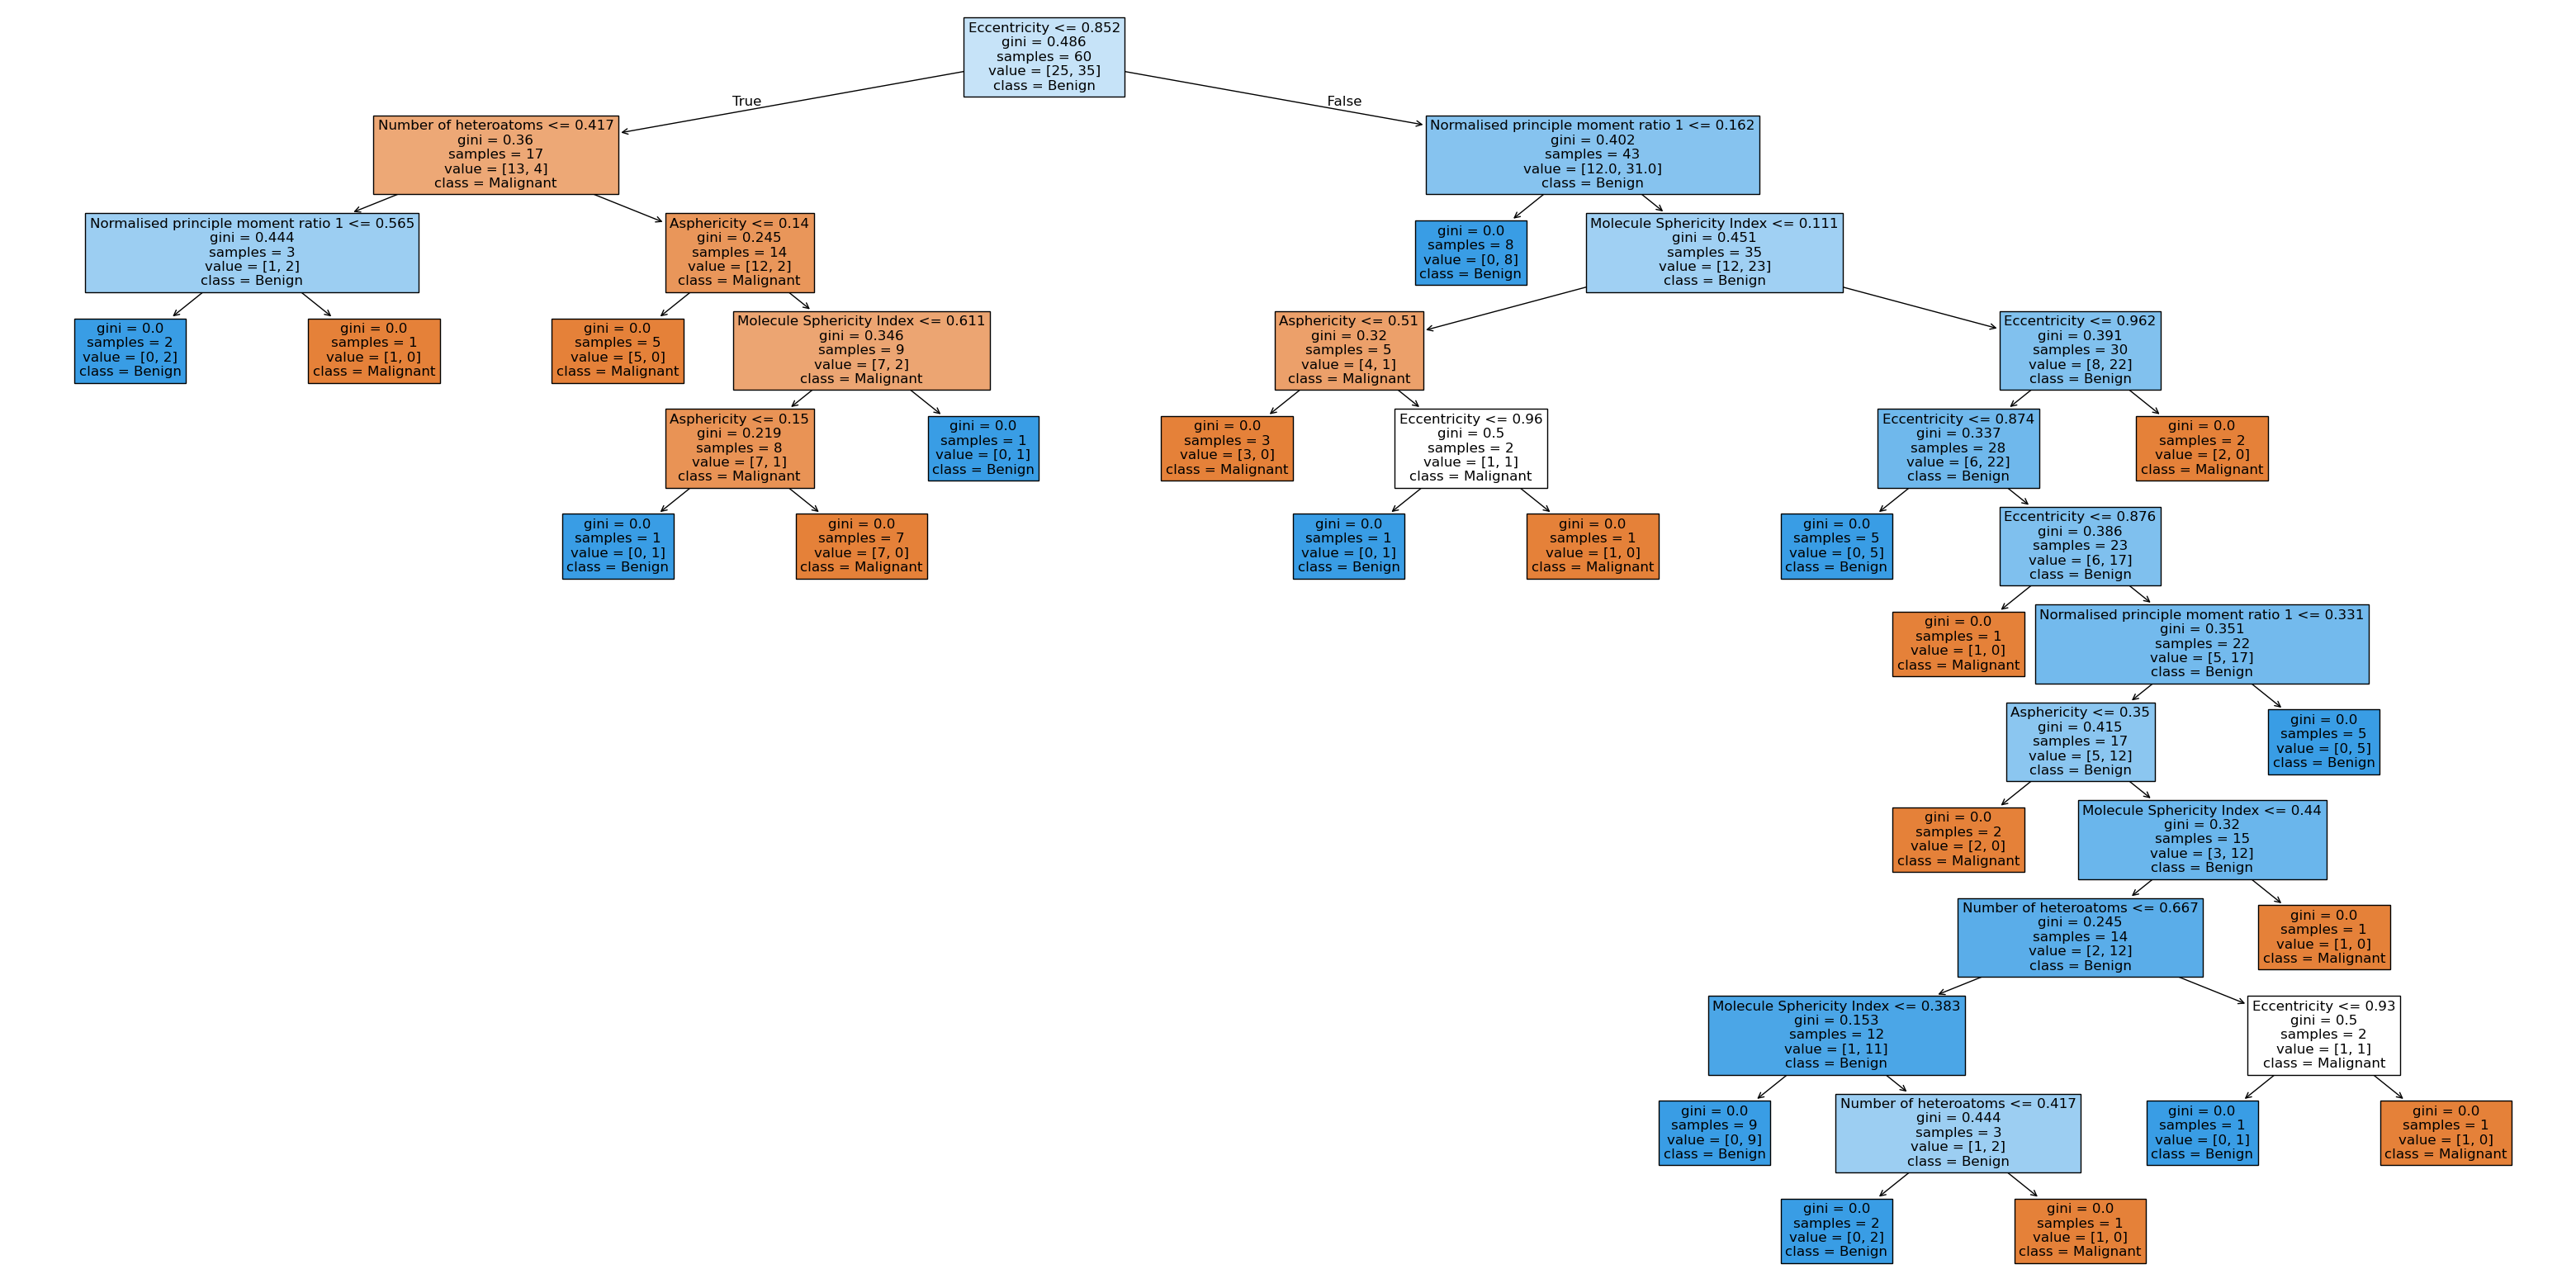

In [ ]:
feature_names = X.columns

from sklearn import tree
from matplotlib import pyplot as plt

fig = plt.figure(figsize=(40,20))
_ = tree.plot_tree(dtc, 
                   feature_names=feature_names,  
                   class_names={0:'Malignant', 1:'Benign'},
                   filled=True,
                  fontsize=12)